## 1. 기본 측정 함수 정의

In [1]:
import numpy as np
from numpy import dot
from numpy.linalg import norm

# 코사인 유사도 측정
def cos_sim(i, j):
    return dot(i, j.T)/(norm(i)*norm(j))

# 집단 A & B에 대한 편향 측정
def s(w, A, B):
    c_a = cos_sim(w, A)
    c_b = cos_sim(w, B)
    mean_A = np.mean(c_a, axis=-1)
    mean_B = np.mean(c_b, axis=-1)
    return mean_A - mean_B

# WEAT Score 측정
def weat_score(X, Y, A, B):
    s_X = s(X, A, B)
    s_Y = s(Y, A, B)
    mean_X = np.mean(s_X)
    mean_Y = np.mean(s_Y)
    std_dev = np.std(np.concatenate([s_X, s_Y], axis=0))
    return  (mean_X-mean_Y)/std_dev

## 2. 사전 학습 임베딩 모델 준비

In [ ]:
!mkdir -p ~/work/weat/data
!ln -s ~/data/* ~/work/weat/data/
!pip install gensim==4.3.2
!pip install scipy==1.12.0 numpy==1.26.2

In [3]:
!pip install "numpy>=1.22.4,<2.0.0"

In [4]:
import os
from gensim.models import KeyedVectors
import numpy as np

data_dir = os.path.join(os.getenv("HOME"), 'work/weat/data')
model_dir = os.path.join(data_dir, 'GoogleNews-vectors-negative300.bin')
w2v = KeyedVectors.load_word2vec_format(model_dir, binary=True, limit=500000)

print(len(w2v.index_to_key)) # vocab size
print(len(w2v['I']))         # 단어를 key로 직접 vector를 얻기
print(w2v.vectors.shape)     # 단어별 shape

500000
300
(500000, 300)


In [5]:
w2v['happy'] # 임베딩 벡터 확인
w2v.most_similar(positive=['happy']) # happy와 가장 유사한 단어 확인

[('glad', 0.7408890724182129),
 ('pleased', 0.6632170677185059),
 ('ecstatic', 0.6626912355422974),
 ('overjoyed', 0.6599286794662476),
 ('thrilled', 0.6514049172401428),
 ('satisfied', 0.6437949538230896),
 ('proud', 0.636042058467865),
 ('delighted', 0.627237856388092),
 ('disappointed', 0.6269949674606323),
 ('excited', 0.6247665286064148)]

## 3. 집단 정의 및 WEAT Score 측정

In [6]:
target_X = ['science', 'technology', 'physics', 'chemistry', 'Einstein', 'NASA', 'experiment', 'astronomy']
target_Y = ['poetry', 'art', 'Shakespeare', 'dance', 'literature', 'novel', 'symphony', 'drama']
attribute_A = ['brother', 'father', 'uncle', 'grandfather', 'son', 'he', 'his', 'him']
attribute_B = ['sister', 'mother', 'aunt', 'grandmother', 'daughter', 'she', 'hers', 'her']

X = np.array([w2v[word] for word in target_X])
Y = np.array([w2v[word] for word in target_Y])
A = np.array([w2v[word] for word in attribute_A])
B = np.array([w2v[word] for word in attribute_B])

print(weat_score(X, Y, A, B))

1.2624874


## 4. 시각화

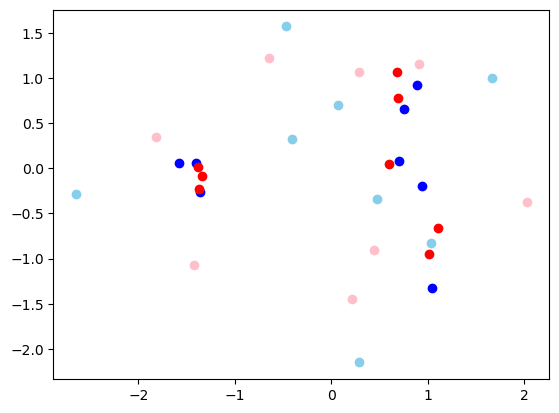

In [7]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pc_A = pca.fit_transform(A)
pc_B = pca.fit_transform(B)
pc_X = pca.fit_transform(X)
pc_Y = pca.fit_transform(Y)

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.scatter(pc_A[:,0],pc_A[:,1], c='blue', label='A')
ax.scatter(pc_B[:,0],pc_B[:,1], c='red', label='B')
ax.scatter(pc_X[:,0],pc_X[:,1], c='skyblue', label='X')
ax.scatter(pc_Y[:,0],pc_Y[:,1], c='pink', label='Y')

## 5. 사전 학습 임베딩모델 제거

In [8]:
del w2v

## 6. 임베딩모델 직접 만들기

In [ ]:
!cd ~/data && unzip synopsis.zip -d ~/work/weat/data/

In [10]:
# synopsis.txt 파일 읽어오기
import os

data_dir = os.path.join(os.getenv("HOME"), "work/weat/data")
file_name = os.path.join(data_dir, "synopsis.txt")

with open(file_name, 'r') as file:
    for i in range(20):
        print(file.readline(), end='')

사운드 엔지니어 상우(유지태 분)는 치매에 걸린 할머니(백성희 분)와
 젊은 시절 상처한 한 아버지(박인환 분), 고모(신신애 분)와 함께 살고 있다.
 어느 겨울 그는 지방 방송국 라디오 PD 은수(이영애 분)를 만난다.
 자연의 소리를 채집해 틀어주는 라디오 프로그램을 준비하는 은수는 상우와 녹음 여행을 떠난다.
 자연스레 가까워지는 두 사람은 어느 날, 은수의 아파트에서 밤을 보낸다.
 너무 쉽게 사랑에 빠진 두 사람... 상우는 주체할 수 없을 정도로 그녀에게 빨려든다.
 그러나 겨울에 만난 두 사람의 관계는 봄을 지나 여름을 맞이하면서 삐걱거린다.
 이혼 경험이 있는 은수는 상우에게 결혼할 생각이 없다며 부담스러운 표정을 내비친다.
 "어떻게 사랑이 변하니?..."라고 묻는 상우에게 은수는 그저 "헤어져" 라고 단호하게 말한다.
 영원히 변할 것 같지 않던 사랑이 변하고, 그 사실을 받아들이지 못하는 상우는 어찌 할 바를 모른다.
 은수를 잊지 못하는 상우는 미련과 집착의 감정을 이기지 못하고 서울과 강릉을 오간다.
유사 이래 연령, 성별, 빈부의 차이와 정치적인 입장을 불문하고 일거에 국민을 통합해 온 '애국심'이라는 성역에 일침을 가하는 다큐멘터리. 재작년 전국 민족민주 유가족협의회의 장기농성을 다룬 인상적인 다큐멘터리 <민들레>를 만들었던 독립영화집단 '빨간 눈사람'이 우리 사회 구석구석을 발빠르게 돌아다니며 애국심과 민족주의가 강요되는 현장을 발굴하여 카메라에 담았다. 박홍 서강대 명예총장, 이도형 '한국논단' 발행인, 축구해설자 신문선, 홍세화, 박노해 등 사회 각계의 '스타'들이 등장해 저마다의 확고한 신념을 성토한다. 감독 이경순과 최하동하는 이 작품을 위해 3년간 백여 명을 인터뷰했다고 한다. 2001 올해의 독립영화상 수상.
 민족과 국가란 공동체에서 부단히 권력과 부를 얻는 자, 나아가 민족과 국가란 공동체에서 얻은 신분과 부귀를 영원히 그의 자손에게 대물림하려는 자, 그래서 민족과 국가란 공동체를 부단히 유지해야만 하는 자, 따라서

In [ ]:
!sudo apt update
!sudo apt install openjdk-17-jdk -y
!echo 'export JAVA_HOME=$(dirname $(dirname $(readlink -f $(which java))))' >> ~/.bashrc
!source ~/.bashrc
!pip install konlpy

In [12]:
# 약 15분정도 걸립니다.
from konlpy.tag import Okt

okt = Okt()
tokenized = []

# 파일에서 품사가 명사인 경우만 남겨 tokenized에 저장
with open(file_name, 'r') as file:
    while True:
        line = file.readline()
        if not line: break
        words = okt.pos(line, stem=True, norm=True)
        res = []
        for w in words:
            if w[1] in ["Noun"]:  # "Adjective", "Verb" 등을 포함할 수도 있습니다.
                res.append(w[0])  # 명사일 때만 tokenized 에 저장하게 됩니다.
        tokenized.append(res)

print("슝~")

슝~


In [13]:
from gensim.models import Word2Vec

# tokenized에 담긴 데이터를 가지고 나만의 Word2Vec을 생성합니다. 
model = Word2Vec(tokenized, vector_size=100, window=5, min_count=3, sg=0)
print(model.wv.most_similar(positive=['영화']))
print(model.wv.most_similar(positive=['사랑']))
print(model.wv.most_similar(positive=['연극']))

[('작품', 0.8939338326454163), ('다큐멘터리', 0.8509050011634827), ('드라마', 0.8235052824020386), ('영화로', 0.8092799186706543), ('주제', 0.7905740737915039), ('형식', 0.7897798418998718), ('코미디', 0.7875202298164368), ('설정', 0.7782480120658875), ('편의', 0.775215744972229), ('감동', 0.7748660445213318)]
[('애정', 0.7290517091751099), ('아르튬', 0.7202470302581787), ('첫사랑', 0.7084406614303589), ('이별', 0.7024502754211426), ('행복', 0.701526939868927), ('진심', 0.6923226118087769), ('연애관', 0.6809313893318176), ('감정', 0.6782252788543701), ('만인', 0.6778380870819092), ('우정', 0.677043080329895)]
[('영화감독', 0.898506224155426), ('시나리오', 0.8850207328796387), ('영감', 0.8814700245857239), ('대본', 0.8745062351226807), ('배우', 0.874480664730072), ('데뷔', 0.8700545430183411), ('캐스팅', 0.8691648840904236), ('연기', 0.8677874207496643), ('예술', 0.8642454743385315), ('예술가', 0.8589504957199097)]


## 7. target 단어 셋 만들기

In [14]:
import os
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from konlpy.tag import Okt

art_txt = 'synopsis_art.txt'
gen_txt = 'synopsis_gen.txt'

def read_token(file_name):
    okt = Okt()
    result = []
    with open(data_dir + '/' + file_name, 'r') as fread:
        print(file_name, '파일을 읽고 있습니다.')
        while True:
            line = fread.readline()
            if not line: break
            tokenlist = okt.pos(line, stem=True, norm=True)
            for word in tokenlist:
                if word[1] in ["Noun"]:#, "Adjective", "Verb"]:
                    result.append((word[0]))
    return ' '.join(result)

# 2개의 파일을 처리하는데 10분 가량 걸립니다.
art = read_token(art_txt)
gen = read_token(gen_txt)

synopsis_art.txt 파일을 읽고 있습니다.
synopsis_gen.txt 파일을 읽고 있습니다.


In [15]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform([art, gen])

print(X.shape)
print(vectorizer.vocabulary_['영화'])
print(vectorizer.get_feature_names_out()[23976])

(2, 41082)
23976
영화


In [16]:
m1 = X[0].tocoo()   # art를 TF-IDF로 표현한 sparse matrix를 가져옵니다.
m2 = X[1].tocoo()   # gen을 TF-IDF로 표현한 sparse matrix를 가져옵니다.

w1 = [[i, j] for i, j in zip(m1.col, m1.data)]
w2 = [[i, j] for i, j in zip(m2.col, m2.data)]

w1.sort(key=lambda x: x[1], reverse=True)   #art를 구성하는 단어들을 TF-IDF가 높은 순으로 정렬합니다.
w2.sort(key=lambda x: x[1], reverse=True)   #gen을 구성하는 단어들을 TF-IDF가 높은 순으로 정렬합니다.

print('예술영화를 대표하는 단어들:')
for i in range(100):
    print(vectorizer.get_feature_names_out()[w1[i][0]], end=', ')

print('일반영화를 대표하는 단어들:')
for i in range(100):
    print(vectorizer.get_feature_names_out()[w2[i][0]], end=', ')

예술영화를 대표하는 단어들:
그녀, 자신, 시작, 위해, 사랑, 사람, 영화, 친구, 남자, 가족, 이야기, 마을, 사건, 마음, 세상, 아버지, 아이, 엄마, 모든, 여자, 대한, 서로, 과연, 시간, 다시, 아들, 소녀, 아내, 다른, 영화제, 사이, 세계, 사실, 하나, 점점, 남편, 감독, 여행, 인생, 발견, 모두, 순간, 우리, 가장, 마지막, 아빠, 생활, 통해, 모습, 기억, 죽음, 비밀, 학교, 음악, 한편, 소년, 생각, 도시, 명의, 결혼, 사고, 전쟁, 위기, 때문, 이제, 최고, 이자, 과거, 일상, 경찰, 간다, 상황, 미국, 운명, 결심, 관계, 현실, 지금, 단편, 여인, 하루, 이름, 이후, 준비, 인간, 만난, 감정, 처음, 국제, 누구, 살인, 충격, 동안, 존재, 그린, 어머니, 연인, 계속, 동생, 작품, 일반영화를 대표하는 단어들:
자신, 그녀, 영화제, 위해, 사람, 시작, 국제, 영화, 친구, 사랑, 남자, 이야기, 대한, 서울, 여자, 사건, 남편, 아이, 가족, 아버지, 다른, 마을, 시간, 엄마, 아들, 모든, 단편, 마음, 사실, 다시, 세계, 모습, 작품, 통해, 생각, 서로, 세상, 발견, 감독, 아내, 관계, 소녀, 사이, 하나, 우리, 애니메이션, 때문, 여성, 죽음, 과연, 점점, 인간, 생활, 한편, 결혼, 상황, 모두, 기억, 명의, 소년, 여행, 가장, 간다, 순간, 이제, 도시, 비밀, 학교, 과거, 가지, 이자, 경찰, 마지막, 미국, 동안, 전쟁, 주인공, 대해, 존재, 현실, 연출, 사고, 살인, 일상, 어머니, 계속, 사회, 인생, 다큐멘터리, 부문, 섹스, 최고, 바로, 의도, 동생, 하루, 위기, 계획, 정체, 한국, 

In [17]:
# 상위 100개의 단어들 중 중복되는 단어를 제외하고 상위 n(=15)개의 단어를 추출
n = 15
w1_, w2_ = [], []
for i in range(100):
    w1_.append(vectorizer.get_feature_names_out()[w1[i][0]])
    w2_.append(vectorizer.get_feature_names_out()[w2[i][0]])

# w1에만 있고 w2에는 없는, 예술영화를 잘 대표하는 단어를 15개 추출한다.
target_art, target_gen = [], []
for i in range(100):
    if (w1_[i] not in w2_) and (w1_[i] in model.wv): target_art.append(w1_[i])
    if len(target_art) == n: break

# w2에만 있고 w1에는 없는, 일반영화를 잘 대표하는 단어를 15개 추출한다.
for i in range(100):
    if (w2_[i] not in w1_) and (w2_[i] in model.wv): target_gen.append(w2_[i])
    if len(target_gen) == n: break

In [18]:
print(target_art)
print(target_gen)

['아빠', '음악', '운명', '결심', '지금', '여인', '이름', '이후', '준비', '만난', '감정', '처음', '누구', '충격', '그린']
['서울', '애니메이션', '여성', '가지', '주인공', '대해', '연출', '사회', '다큐멘터리', '부문', '섹스', '바로', '의도', '계획', '정체']


## 8. attribute 단어 셋 만들기

In [19]:
genre_txt = ['synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt', 'synopsis_horror.txt', 'synopsis_etc.txt',
             'synopsis_documentary.txt', 'synopsis_drama.txt', 'synopsis_romance.txt', 'synopsis_musical.txt',
             'synopsis_mystery.txt', 'synopsis_crime.txt', 'synopsis_historical.txt', 'synopsis_western.txt',
             'synopsis_adult.txt', 'synopsis_thriller.txt', 'synopsis_animation.txt', 'synopsis_action.txt',
             'synopsis_adventure.txt', 'synopsis_war.txt', 'synopsis_comedy.txt', 'synopsis_fantasy.txt']
genre_name = ['SF', '가족', '공연', '공포(호러)', '기타', '다큐멘터리', '드라마', '멜로로맨스', '뮤지컬', '미스터리', '범죄', '사극', '서부극(웨스턴)',
         '성인물(에로)', '스릴러', '애니메이션', '액션', '어드벤처', '전쟁', '코미디', '판타지']

# 약 10분정도 걸립니다.
genre = []
for file_name in genre_txt:
    genre.append(read_token(file_name))

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(genre)

print(X.shape)

synopsis_SF.txt 파일을 읽고 있습니다.
synopsis_family.txt 파일을 읽고 있습니다.
synopsis_show.txt 파일을 읽고 있습니다.
synopsis_horror.txt 파일을 읽고 있습니다.
synopsis_etc.txt 파일을 읽고 있습니다.
synopsis_documentary.txt 파일을 읽고 있습니다.
synopsis_drama.txt 파일을 읽고 있습니다.
synopsis_romance.txt 파일을 읽고 있습니다.
synopsis_musical.txt 파일을 읽고 있습니다.
synopsis_mystery.txt 파일을 읽고 있습니다.
synopsis_crime.txt 파일을 읽고 있습니다.
synopsis_historical.txt 파일을 읽고 있습니다.
synopsis_western.txt 파일을 읽고 있습니다.
synopsis_adult.txt 파일을 읽고 있습니다.
synopsis_thriller.txt 파일을 읽고 있습니다.
synopsis_animation.txt 파일을 읽고 있습니다.
synopsis_action.txt 파일을 읽고 있습니다.
synopsis_adventure.txt 파일을 읽고 있습니다.
synopsis_war.txt 파일을 읽고 있습니다.
synopsis_comedy.txt 파일을 읽고 있습니다.
synopsis_fantasy.txt 파일을 읽고 있습니다.
(21, 42191)


In [20]:
m = [X[i].tocoo() for i in range(X.shape[0])]

w = [[[i, j] for i, j in zip(mm.col, mm.data)] for mm in m]

for i in range(len(w)):
    w[i].sort(key=lambda x: x[1], reverse=True)
attributes = []
for i in range(len(w)):
    print(genre_name[i], end=': ')
    attr = []
    j = 0
    while (len(attr) < 15):
        if vectorizer.get_feature_names_out()[w[i][j][0]] in model.wv:
            attr.append(vectorizer.get_feature_names_out()[w[i][j][0]])
            print(vectorizer.get_feature_names_out()[w[i][j][0]], end=', ')
        j += 1
    attributes.append(attr)
    print()

SF: 위해, 자신, 지구, 시작, 사람, 인류, 인간, 미래, 우주, 그녀, 로봇, 세계, 모든, 박사, 우주선, 
가족: 엄마, 아빠, 가족, 영화제, 자신, 위해, 친구, 아주르, 아버지, 시작, 그녀, 아들, 국제, 마을, 낙타, 
공연: 오페라, 사랑, 토스카, 실황, 올레, 자신, 카바, 그녀, 공연, 오텔로, 리골레토, 백작, 프레, 베르디, 위해, 
공포(호러): 시작, 위해, 사람, 자신, 친구, 그녀, 사건, 공포, 발견, 죽음, 마을, 가족, 악령, 남자, 좀비, 
기타: 영화제, 국제, 서울, 단편, 영화, 자신, 사람, 이야기, 그녀, 남자, 위해, 시작, 사랑, 뉴미디어, 페스티벌, 
다큐멘터리: 영화제, 영화, 다큐, 국제, 다큐멘터리, 사람, 이야기, 대한, 자신, 감독, 위해, 서울, 우리, 시작, 세계, 
드라마: 자신, 영화제, 그녀, 사람, 사랑, 영화, 위해, 시작, 국제, 남자, 친구, 이야기, 엄마, 여자, 아버지, 
멜로로맨스: 그녀, 사랑, 자신, 시작, 남편, 남자, 여자, 사람, 친구, 섹스, 위해, 마음, 결혼, 서로, 아내, 
뮤지컬: 뮤지컬, 사랑, 에스메랄다, 그녀, 음악, 충무로, 모차르트, 영화, 토스카, 자신, 니웨, 카바, 영화제, 바흐, 프롤, 
미스터리: 사건, 그녀, 시작, 자신, 위해, 사람, 발견, 사고, 진실, 죽음, 기억, 살인, 친구, 아내, 아이, 
범죄: 사건, 위해, 자신, 경찰, 시작, 그녀, 범죄, 조직, 살인, 사람, 마약, 형사, 남자, 모든, 살해, 
사극: 조선, 위해, 시작, 신기전, 사랑, 자신, 아가멤논, 황제, 그녀, 루안, 사람, 운명, 최고, 하선, 전쟁, 
서부극(웨스턴): 서부, 보안관, 위해, 벌린, 카우보이, 그레이프바인, 헨리, 마을, 자신, 개릿, 아이, 시작, 무법자, 프린트, 태구, 
성인물(에로): 그녀, 남편, 마사지, 자신, 섹스, 관계, 영화, 정사, 남자, 위해, 시작, 여자, 유부녀, 마음, 사랑, 
스릴러: 자신, 그녀, 사건, 시

## 9. WEAT Score 측정

In [21]:
# target_X 는 art, target_Y 는 gen으로 고정하고 attribute_A, attribute_B를 바꿔가면서 측정
# 측정 결과를 21x21 매트릭스 형태로 표현해서 matrix 라는 변수에 담기

matrix = [[0 for _ in range(len(genre_name))] for _ in range(len(genre_name))]

X = np.array([model.wv[word] for word in target_art])
Y = np.array([model.wv[word] for word in target_gen])

for i in range(len(genre_name)-1):
    for j in range(i+1, len(genre_name)):
        A = np.array([model.wv[word] for word in attributes[i]])
        B = np.array([model.wv[word] for word in attributes[j]])
        matrix[i][j] = weat_score(X, Y, A, B)

for i in range(len(genre_name)-1):
    for j in range(i+1, len(genre_name)):
        print(genre_name[i], genre_name[j],matrix[i][j])

SF 가족 -0.52570707
SF 공연 -0.35368797
SF 공포(호러) -0.6630573
SF 기타 0.36036846
SF 다큐멘터리 0.5954811
SF 드라마 -0.3572022
SF 멜로로맨스 -0.78885514
SF 뮤지컬 0.36723712
SF 미스터리 -0.660934
SF 범죄 -0.18732037
SF 사극 -0.83827394
SF 서부극(웨스턴) -0.47032982
SF 성인물(에로) -0.57008743
SF 스릴러 -0.49353823
SF 애니메이션 0.35033032
SF 액션 -0.41313475
SF 어드벤처 -0.801789
SF 전쟁 0.18305156
SF 코미디 -0.42026493
SF 판타지 -0.09460318
가족 공연 0.23400956
가족 공포(호러) -0.14465106
가족 기타 0.768469
가족 다큐멘터리 0.8390782
가족 드라마 0.27276233
가족 멜로로맨스 -0.6041811
가족 뮤지컬 0.73141545
가족 미스터리 -0.25403097
가족 범죄 0.26381218
가족 사극 -0.06576401
가족 서부극(웨스턴) 0.32940426
가족 성인물(에로) -0.30451462
가족 스릴러 -0.09974242
가족 애니메이션 0.8662382
가족 액션 0.15189873
가족 어드벤처 -0.0011116747
가족 전쟁 0.6329893
가족 코미디 0.25872177
가족 판타지 0.4682397
공연 공포(호러) -0.2620552
공연 기타 0.91869193
공연 다큐멘터리 0.9058137
공연 드라마 0.0045421454
공연 멜로로맨스 -0.704748
공연 뮤지컬 0.882534
공연 미스터리 -0.32775906
공연 범죄 0.09754028
공연 사극 -0.40861967
공연 서부극(웨스턴) -0.04687848
공연 성인물(에로) -0.49010453
공연 스릴러 -0.21049727
공연 애니메이션 0.8581096
공연 액션 -0.

## 10. 시각화

In [36]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import os

# 폴더 생성 및 폰트 다운로드
os.makedirs(os.path.expanduser('~/.fonts'), exist_ok=True)
!wget -q https://github.com/naver/nanumfont/releases/download/VER2.5/NanumGothicCoding-2.5.zip -O /tmp/nanum.zip
!unzip -o /tmp/nanum.zip -d ~/.fonts/

# 다운로드 확인
!ls ~/.fonts/

Archive:  /tmp/nanum.zip
  inflating: /home/jovyan/.fonts/NanumGothicCoding-Bold.ttf  
   creating: /home/jovyan/.fonts/__MACOSX/
  inflating: /home/jovyan/.fonts/__MACOSX/._NanumGothicCoding-Bold.ttf  
  inflating: /home/jovyan/.fonts/NanumGothicCoding.ttf  
  inflating: /home/jovyan/.fonts/__MACOSX/._NanumGothicCoding.ttf  
NanumGothicCoding-Bold.ttf  NanumGothicCoding.ttf  __MACOSX


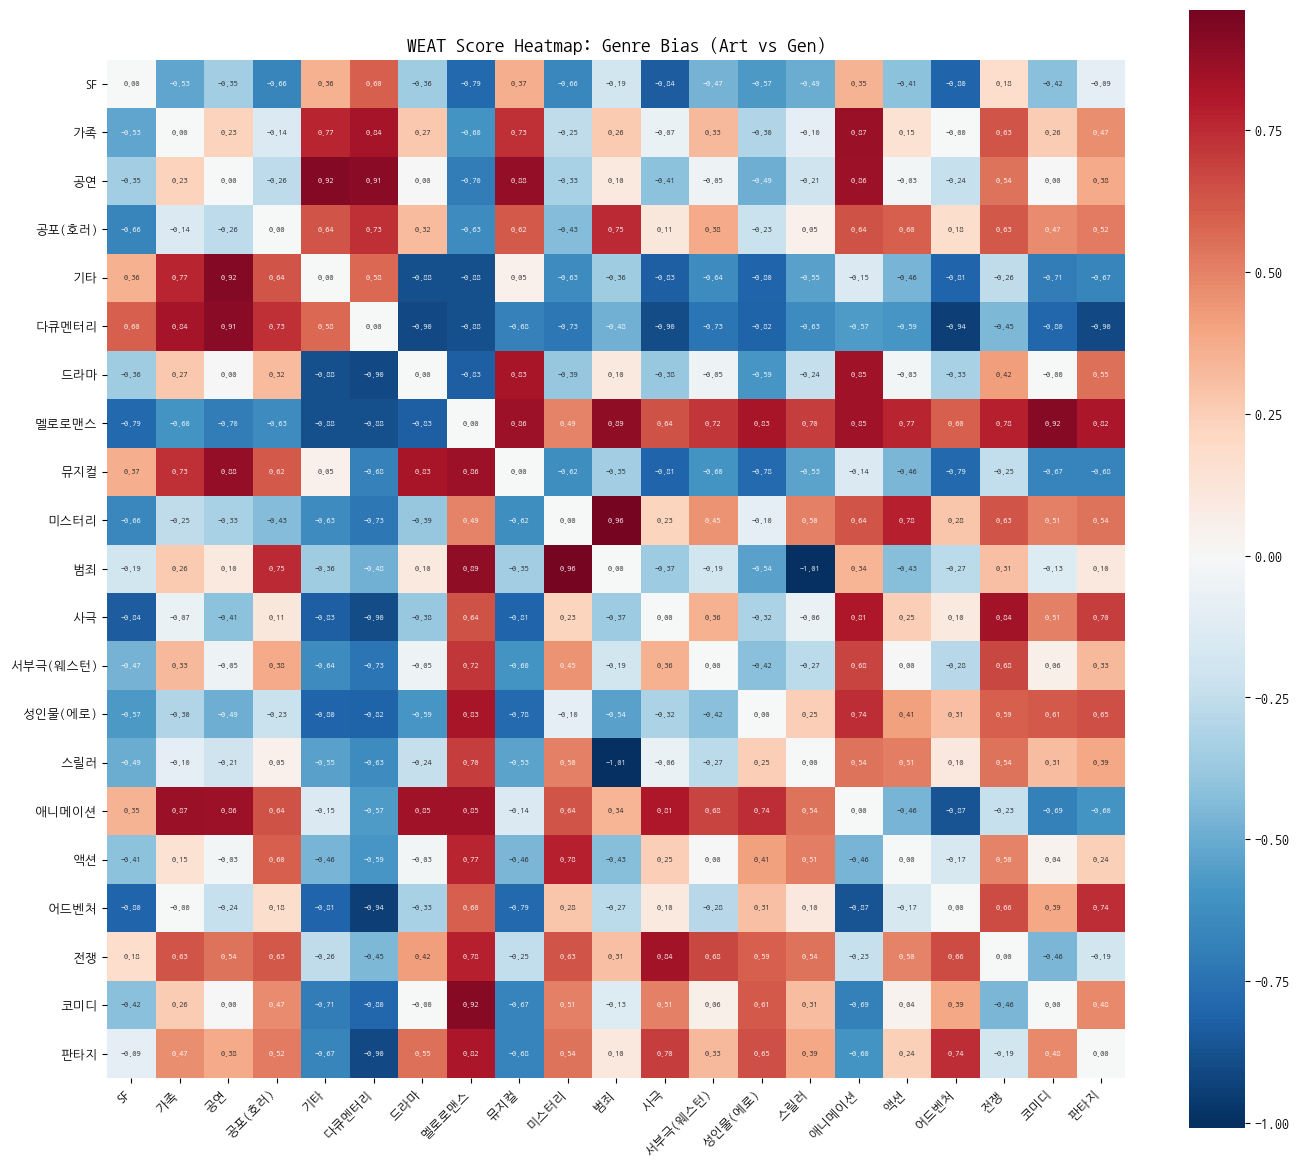

In [40]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import os

# 폰트 등록
font_path = os.path.expanduser('~/.fonts/NanumGothicCoding.ttf')
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothicCoding'
plt.rcParams['axes.unicode_minus'] = False

import seaborn as sns

# 대칭 행렬로 변환 (상삼각 → 전체)
matrix_full = np.array(matrix)
matrix_full = matrix_full + matrix_full.T  # 하삼각에 복사

plt.figure(figsize=(14, 12))
sns.heatmap(matrix_full, 
            xticklabels=genre_name, 
            yticklabels=genre_name,
            cmap='RdBu_r',  # 빨강-파랑 색상 (양수/음수 구분)
            center=0,       # 0을 중심으로 색상 배치
            annot=True,     # 값 표시
            fmt='.2f',      # 소수점 2자리
            annot_kws={'size': 6},  # 폰트 크기
            square=True)

plt.title('WEAT Score Heatmap: Genre Bias (Art vs Gen)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('weat_heatmap.png', dpi=150)
plt.show()